# T20 Win Probability — Showcase

A thin walkthrough of the finished model. Every cell **reuses functions from
`src/t20wp`** (no logic is re-implemented here): it loads the production
calibrated-XGBoost model plus the pre-computed per-ball WPA table and then

1. draws the win-probability trajectory of the **2016 ICC World T20 final**
   (`match_id` `951373`) with `t20wp.evaluate.plot_wp_trajectory`,
2. shows the **reliability diagram** on the held-out test set with
   `t20wp.evaluate.calibration_table` / `plot_calibration` and reports
   ECE/MCE via `reliability_stats`,
3. displays the **IPL clutch leaderboard** (batters and bowlers) built in
   Phase 4.

Reproduce the artifacts with
`run_ingest → run_features → run_eval → run_wpa` (see the README).

In [1]:
# Make src/ (the t20wp package) and scripts/ importable, then reuse them.
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "t20wp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for sub in ("src", "scripts"):
    p = str(ROOT / sub)
    if p not in sys.path:
        sys.path.insert(0, p)

import json

import pandas as pd
from IPython.display import Image, display

from t20wp.evaluate import (
    calibration_table,
    plot_calibration,
    plot_wp_trajectory,
    reliability_stats,
)
from t20wp.models import load_model
# build_trajectory lives in the Phase-3 entry script; reuse it verbatim.
from run_eval import build_trajectory

print("repo root:", ROOT)

repo root: /code/Ridham-Shah-25/T20_Win_Probability_Model


## Load the production model and pre-computed artifacts

The calibrated XGBoost (`models/xgb_calibrated.joblib`) is the production model
used for WPA. We also load the frozen feature table, raw ball events, the split
definition, the per-ball WPA table (`models/wpa_balls.parquet`), and the
held-out test predictions written by `run_eval.py`.

In [2]:
model = load_model(ROOT / "models" / "xgb_calibrated.joblib")

features = pd.read_parquet(ROOT / "data/processed/features.parquet")
balls = pd.read_parquet(ROOT / "data/processed/balls.parquet")
splits = json.loads((ROOT / "data/processed/splits.json").read_text())
wpa_balls = pd.read_parquet(ROOT / "models" / "wpa_balls.parquet")
test_preds = pd.read_parquet(ROOT / "models" / "test_predictions.parquet")

print(f"features rows : {len(features):,}")
print(f"wpa_balls rows: {len(wpa_balls):,}")
print(f"test preds    : {len(test_preds):,} rows, {test_preds['match_id'].nunique()} matches")

features rows : 1,040,499
wpa_balls rows: 1,040,499
test preds    : 152,677 rows, 662 matches


## 1. Win-probability trajectory — 2016 World T20 final (`951373`)

West Indies chased 156 against England and Carlos Brathwaite hit four sixes in
the final over. We rebuild the per-ball trajectory with `build_trajectory`
(scoring every ball with the calibrated model) and plot it on a **fixed West
Indies perspective** with `plot_wp_trajectory`. Red markers are wickets, green
markers are fours/sixes; the dashed vertical line is the innings break.

trajectory rows: 245 | final WI wp: 0.978


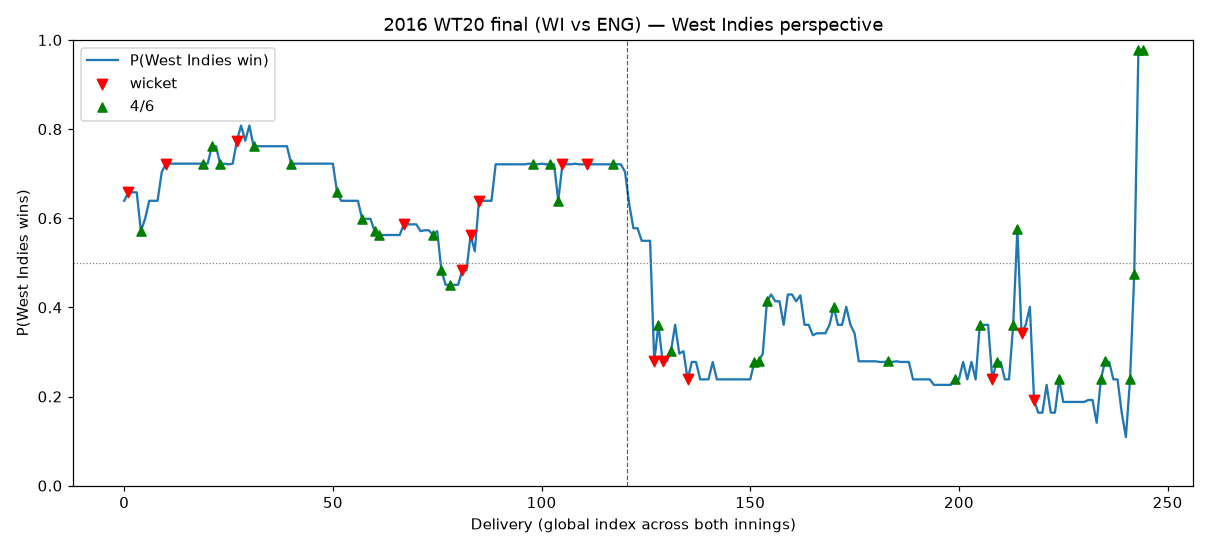

In [3]:
traj = build_trajectory(features, balls, "951373", model)

fig_out = ROOT / "notebooks" / "_wp_951373.png"
plot_wp_trajectory(
    traj,
    fig_out,
    "2016 WT20 final (WI vs ENG) — West Indies perspective",
    team="West Indies",
)
print(f"trajectory rows: {len(traj)} | final WI wp: {traj['wp'].iloc[-1]:.3f}")
display(Image(filename=str(fig_out)))

## 2. Calibration on the held-out test set

Reliability diagram for all three models on the test predictions, reusing
`calibration_table` + `plot_calibration`, with ECE/MCE from `reliability_stats`.
A well-calibrated model tracks the diagonal.

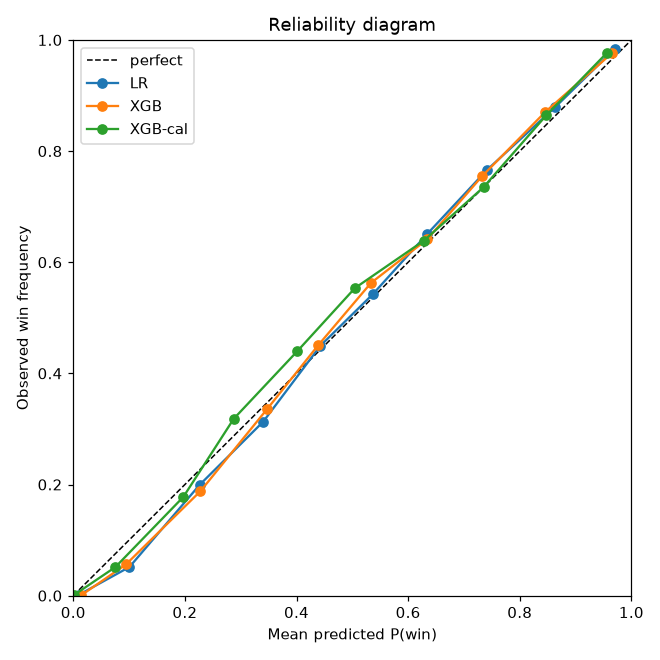

Calibration error (overall test):


,ece,mce
LR,0.0196,0.0491
XGB,0.0210,0.0398
XGB-cal,0.0211,0.0488


In [4]:
prob_cols = {"LR": "p_lr", "XGB": "p_xgb", "XGB-cal": "p_cal"}
y = test_preds["won"].values

curves = {name: calibration_table(y, test_preds[col].values) for name, col in prob_cols.items()}

cal_out = ROOT / "notebooks" / "_calibration.png"
plot_calibration(curves, cal_out)
display(Image(filename=str(cal_out)))

rel = pd.DataFrame(
    {name: reliability_stats(y, test_preds[col].values) for name, col in prob_cols.items()}
).T.round(4)
print("Calibration error (overall test):")
rel

## 3. IPL clutch leaderboard (WPA, all seasons)

Per-ball ΔWP is credited `+ΔWP` to the striker and `−ΔWP` to the bowler; summed
over all IPL balls (min 300 balls per player) this gives a "clutch" ranking.
Read straight from the Phase-4 CSVs.

In [5]:
ipl_batters = pd.read_csv(ROOT / "reports/wpa/ipl_batter_clutch_allseasons.csv")
ipl_bowlers = pd.read_csv(ROOT / "reports/wpa/ipl_bowler_clutch_allseasons.csv")

print("Top 10 IPL clutch batters (all seasons):")
display(ipl_batters.head(10))
print("Top 10 IPL clutch bowlers (all seasons):")
display(ipl_bowlers.head(10))

Top 10 IPL clutch batters (all seasons):


,batter,clutch,balls
0,AB de Villiers,10.060694,3411
1,CH Gayle,7.353339,3367
2,V Sehwag,6.841395,1787
3,JC Buttler,6.414274,3131
4,KA Pollard,6.066830,2433
5,AD Russell,5.772538,1586
6,DA Warner,5.647013,4697
7,SK Raina,5.403089,4102
8,V Kohli,5.295537,7022
9,RR Pant,5.237375,2658


Top 10 IPL clutch bowlers (all seasons):


,bowler,clutch,balls
0,SP Narine,11.667032,4583
1,B Kumar,10.162778,4666
2,JJ Bumrah,6.951030,3743
3,Rashid Khan,6.913110,3516
4,SL Malinga,6.646227,2974
5,R Ashwin,6.575830,4737
6,DW Steyn,4.606501,2228
7,YS Chahal,4.562553,4117
8,Harbhajan Singh,3.944042,3496
9,M Muralitharan,3.376415,1528
